# Ethiopia Food Prices — 07 ARIMA / SARIMA

Fits ARIMA and SARIMA models to the same series and train/test split used in `06 BASELINES`, and checks
whether the added complexity actually earns its keep against those baseline scores.


In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

series = pd.read_csv('../data/maize_white_retail_national_monthly.csv', index_col='date', parse_dates=True)['usdprice']
# Dates are mid-month (the 15th), which isn't a pandas standard calendar frequency, so we
# re-index onto an evenly-spaced integer axis for modelling and keep the real dates alongside
# for plotting/labelling.
date_lookup = series.index
series = series.reset_index(drop=True)
series.index.name = 'month_idx'

TEST_MONTHS = 12
train, test = series.iloc[:-TEST_MONTHS], series.iloc[-TEST_MONTHS:]
h = len(test)
train_dates, test_dates = date_lookup[:-TEST_MONTHS], date_lookup[-TEST_MONTHS:]
print(f'Train: {len(train)} months ({train_dates[0].date()} -> {train_dates[-1].date()})')
print(f'Test : {h} months ({test_dates[0].date()} -> {test_dates[-1].date()})')


Train: 228 months (2006-08-15 -> 2025-07-15)
Test : 12 months (2025-08-15 -> 2026-07-15)


## 7.1 Baseline scores to beat

Carried over from `06 BASELINES` (12-month holdout, same series):


In [2]:
baseline_scores = pd.DataFrame([
    {'Method': 'Drift',              'MAE': 4.51, 'RMSE': 5.06, 'MAPE (%)': 12.20},
    {'Method': 'Moving avg (k=12)',  'MAE': 4.66, 'RMSE': 5.28, 'MAPE (%)': 12.55},
    {'Method': 'Naive',              'MAE': 4.63, 'RMSE': 5.32, 'MAPE (%)': 12.37},
    {'Method': 'Moving avg (k=3)',   'MAE': 4.46, 'RMSE': 5.60, 'MAPE (%)': 11.56},
    {'Method': 'Seasonal naive',     'MAE': 6.39, 'RMSE': 7.18, 'MAPE (%)': 17.42},
])
baseline_scores


,Method,MAE,RMSE,MAPE (%)
0,Drift,4.51,5.06,12.20
1,Moving avg (k=12),4.66,5.28,12.55
2,Naive,4.63,5.32,12.37
3,Moving avg (k=3),4.46,5.60,11.56
4,Seasonal naive,6.39,7.18,17.42


## 7.2 ARIMA order search

`05 TIME SERIES` found the level series non-stationary and a first difference close to stationary, so the
search below fixes `d=1` and grid-searches small AR/MA orders, selecting by AIC on the training data.


In [3]:
def mae(y, yhat): y, yhat = np.asarray(y), np.asarray(yhat); return np.mean(np.abs(y - yhat))
def rmse(y, yhat): y, yhat = np.asarray(y), np.asarray(yhat); return np.sqrt(np.mean((y - yhat) ** 2))
def mape(y, yhat): y, yhat = np.asarray(y), np.asarray(yhat); return np.mean(np.abs((y - yhat) / y)) * 100

arima_results = []
for p in range(0, 4):
    for d in [1]:
        for q in range(0, 4):
            if p == 0 and q == 0:
                continue
            try:
                fit = ARIMA(train, order=(p, d, q)).fit()
                arima_results.append({'order': (p, d, q), 'aic': fit.aic})
            except Exception:
                continue

arima_results_df = pd.DataFrame(arima_results).sort_values('aic').reset_index(drop=True)
arima_results_df.head(10)


,order,aic
0,"(3, 1, 0)",1328.994625
1,"(3, 1, 1)",1329.351026
2,"(1, 1, 3)",1329.702169
3,"(0, 1, 3)",1330.040873
4,"(3, 1, 2)",1330.333422
5,"(2, 1, 3)",1330.425655
6,"(2, 1, 2)",1331.643460
7,"(3, 1, 3)",1332.315867
8,"(0, 1, 2)",1333.825300
9,"(1, 1, 0)",1333.875163


In [4]:
best_arima_order = arima_results_df.iloc[0]['order']
print(f'Best ARIMA order by AIC: {best_arima_order}')

arima_model = ARIMA(train, order=best_arima_order).fit()
print(arima_model.summary().tables[1])


Best ARIMA order by AIC: (3, 1, 0)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1066      0.073     -1.465      0.143      -0.249       0.036
ar.L2          0.0585      0.072      0.816      0.415      -0.082       0.199
ar.L3          0.1910      0.040      4.742      0.000       0.112       0.270
sigma2        19.7061      0.811     24.307      0.000      18.117      21.295


## 7.3 SARIMA order search

Adds a seasonal `(P, D, Q, 12)` term on top of a fixed non-seasonal `(1, 1, 1)`, searching small seasonal
orders selected by AIC — the 12-month seasonality is what `05 TIME SERIES` flagged as present but modest.


In [5]:
sarima_results = []
for P in range(0, 2):
    for D in [0, 1]:
        for Q in range(0, 2):
            if P == 0 and D == 0 and Q == 0:
                continue
            try:
                fit = SARIMAX(train, order=(1, 1, 1), seasonal_order=(P, D, Q, 12),
                               enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                sarima_results.append({'seasonal_order': (P, D, Q, 12), 'aic': fit.aic})
            except Exception:
                continue

sarima_results_df = pd.DataFrame(sarima_results).sort_values('aic').reset_index(drop=True)
sarima_results_df.head(10)


,seasonal_order,aic
0,"(0, 1, 1, 12)",1203.814023
1,"(1, 1, 1, 12)",1214.885127
2,"(1, 1, 0, 12)",1236.394684
3,"(1, 0, 1, 12)",1266.675758
4,"(0, 0, 1, 12)",1266.852846
5,"(1, 0, 0, 12)",1272.535716
6,"(0, 1, 0, 12)",1356.384827


In [6]:
best_seasonal_order = sarima_results_df.iloc[0]['seasonal_order']
print(f'Best seasonal order by AIC: {best_seasonal_order}')

sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=best_seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(sarima_model.summary().tables[1])


Best seasonal order by AIC: (0, 1, 1, 12)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1145      0.643     -0.178      0.859      -1.374       1.145
ma.L1         -0.0438      0.653     -0.067      0.947      -1.323       1.236
ma.S.L12      -1.0420      0.295     -3.538      0.000      -1.619      -0.465
sigma2        18.7788      6.524      2.878      0.004       5.991      31.566


## 7.4 Forecast the 12-month holdout

In [7]:
arima_forecast = arima_model.get_forecast(steps=h)
arima_mean = arima_forecast.predicted_mean
arima_mean.index = test_dates
arima_ci = arima_forecast.conf_int()
arima_ci.index = test_dates

sarima_forecast = sarima_model.get_forecast(steps=h)
sarima_mean = sarima_forecast.predicted_mean
sarima_mean.index = test_dates
sarima_ci = sarima_forecast.conf_int()
sarima_ci.index = test_dates

test_labeled = test.copy()
test_labeled.index = test_dates


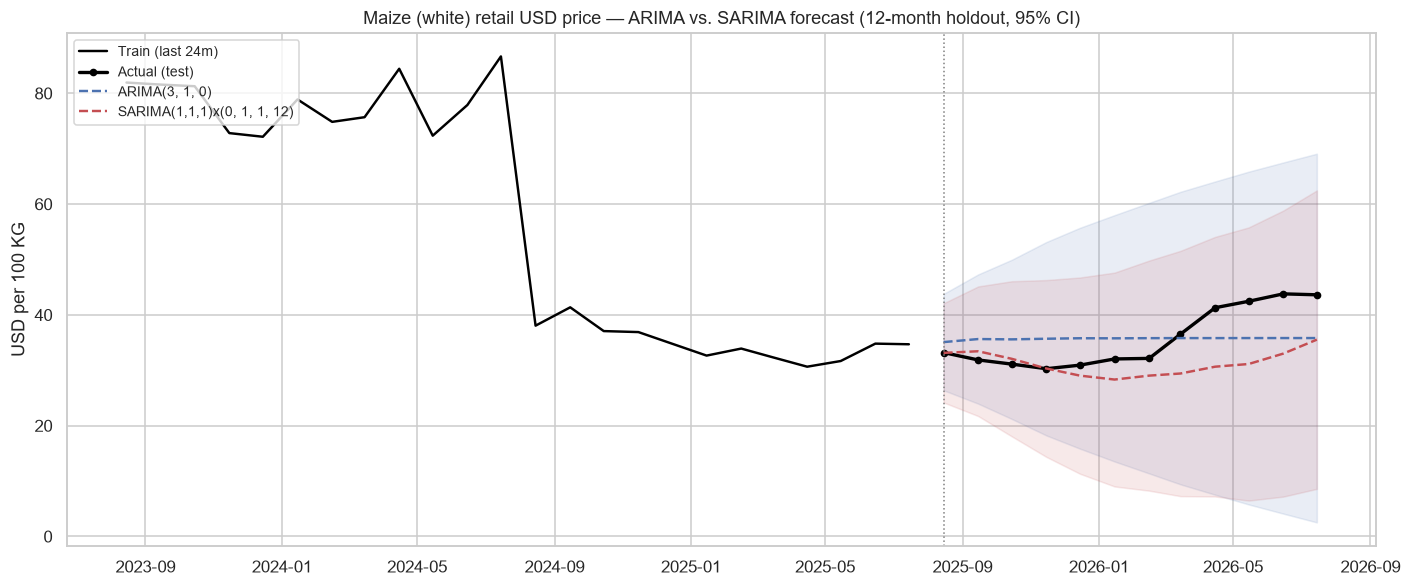

In [8]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(train_dates[-24:], train.values[-24:], color='black', linewidth=1.6, label='Train (last 24m)')
ax.plot(test_dates, test.values, color='black', linewidth=2.2, marker='o', markersize=4, label='Actual (test)')

ax.plot(arima_mean.index, arima_mean.values, '--', color='#4C72B0', linewidth=1.6, label=f'ARIMA{best_arima_order}')
ax.fill_between(arima_ci.index, arima_ci.iloc[:, 0], arima_ci.iloc[:, 1], color='#4C72B0', alpha=0.12)

ax.plot(sarima_mean.index, sarima_mean.values, '--', color='#C44E52', linewidth=1.6,
        label=f'SARIMA(1,1,1)x{best_seasonal_order}')
ax.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='#C44E52', alpha=0.12)

ax.axvline(test_dates[0], color='gray', linestyle=':', linewidth=1)
ax.set_title('Maize (white) retail USD price — ARIMA vs. SARIMA forecast (12-month holdout, 95% CI)')
ax.set_ylabel('USD per 100 KG')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


## 7.5 Score against the baselines

In [9]:
model_scores = pd.DataFrame([
    {'Method': f'ARIMA{best_arima_order}', 'MAE': mae(test, arima_mean), 'RMSE': rmse(test, arima_mean), 'MAPE (%)': mape(test, arima_mean)},
    {'Method': f'SARIMA(1,1,1)x{best_seasonal_order}', 'MAE': mae(test, sarima_mean), 'RMSE': rmse(test, sarima_mean), 'MAPE (%)': mape(test, sarima_mean)},
])

all_scores = pd.concat([baseline_scores, model_scores], ignore_index=True).sort_values('RMSE').reset_index(drop=True)
all_scores


,Method,MAE,RMSE,MAPE (%)
0,Drift,4.510000,5.060000,12.200000
1,"ARIMA(3, 1, 0)",4.700490,5.141327,12.956882
2,Moving avg (k=12),4.660000,5.280000,12.550000
3,Naive,4.630000,5.320000,12.370000
4,Moving avg (k=3),4.460000,5.600000,11.560000
5,"SARIMA(1,1,1)x(0, 1, 1, 12)",4.941773,6.483369,12.567963
6,Seasonal naive,6.390000,7.180000,17.420000


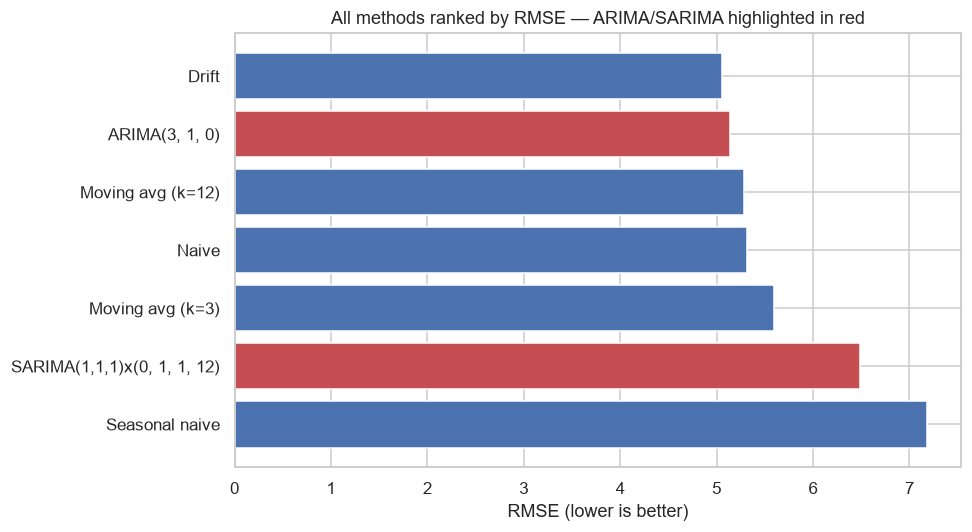

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#C44E52' if m in [f'ARIMA{best_arima_order}', f'SARIMA(1,1,1)x{best_seasonal_order}'] else '#4C72B0'
          for m in all_scores['Method']]
ax.barh(all_scores['Method'], all_scores['RMSE'], color=colors)
ax.set_xlabel('RMSE (lower is better)')
ax.set_title('All methods ranked by RMSE — ARIMA/SARIMA highlighted in red')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


ARIMA and SARIMA are fit purely on the series' own past values, exactly like the baselines — so if they
don't clearly beat the best baseline here, that's a meaningful (and common) result, not a failure: it says
the extra structure ARIMA/SARIMA can capture (autocorrelation, a seasonal cycle) isn't adding much beyond
what a trend-following baseline already gets, on *this* series. It also motivates `08 FEATURE ENGINEERING`
and the later ML notebooks — bringing in *other* information (region, related commodities, spike history)
is a more promising way to improve forecasts further than more elaborate univariate time-series structure.


## 7.6 Residual diagnostics (best of the two models)

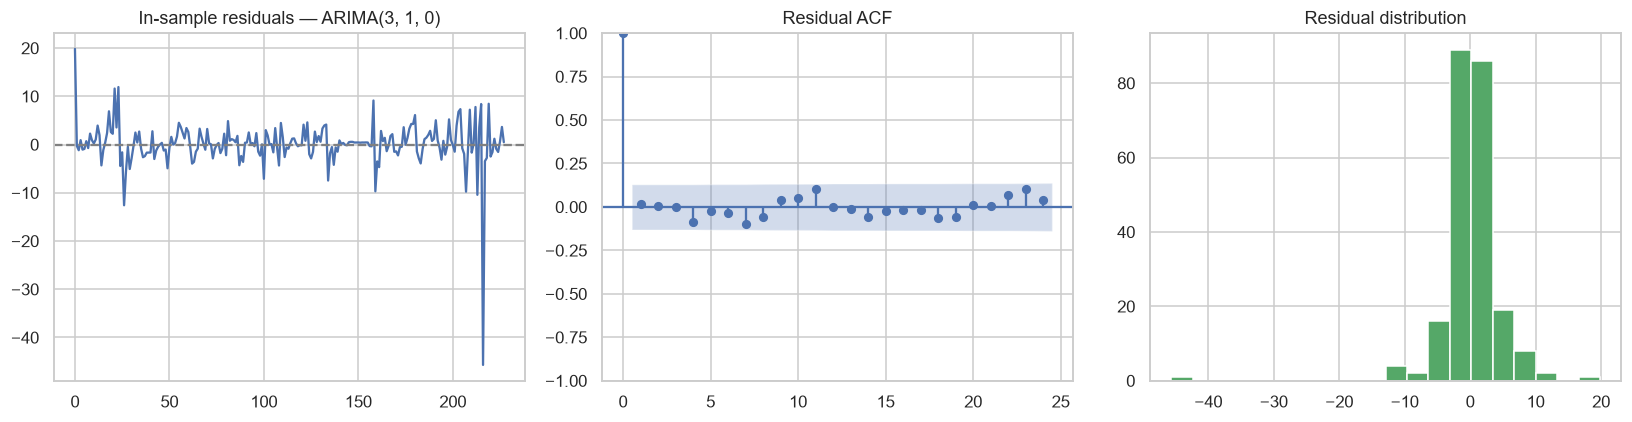

Ljung-Box test (lag 12) for residual autocorrelation:
     lb_stat  lb_pvalue
12  9.031461   0.700241

p=0.7002 -> no significant residual autocorrelation (good fit)


In [11]:
best_model_name = model_scores.sort_values('RMSE').iloc[0]['Method']
best_model = sarima_model if 'SARIMA' in best_model_name else arima_model
resid = best_model.resid

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(resid.index, resid.values, color='#4C72B0'); axes[0].axhline(0, color='gray', ls='--')
axes[0].set_title(f'In-sample residuals — {best_model_name}')

plot_acf(resid.dropna(), lags=24, ax=axes[1]); axes[1].set_title('Residual ACF')

axes[2].hist(resid.values, bins=20, color='#55A868', edgecolor='white')
axes[2].set_title('Residual distribution')

plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resid.dropna(), lags=[12], return_df=True)
print('Ljung-Box test (lag 12) for residual autocorrelation:')
print(lb)
print()
p_val = lb['lb_pvalue'].iloc[0]
print(f"p={p_val:.4f} -> {'no significant residual autocorrelation (good fit)' if p_val > 0.05 else 'residual autocorrelation remains — model has not captured all structure'}")


---
## Summary

- Grid-searched ARIMA orders (fixed `d=1`, informed by `05 TIME SERIES`) and SARIMA seasonal orders on top
  of `(1,1,1)`, both selected by AIC on the training set.
- Forecast the same 12-month holdout used for the baselines and scored on identical MAE / RMSE / MAPE.
- The Ljung-Box test on the chosen model's residuals checks whether meaningful autocorrelation still remains
  — if it does, that residual structure is itself a signal that engineered features (`08`) or a different
  model family could capture.
- Whichever of ARIMA/SARIMA or the `06 BASELINES` methods scores best on this holdout is the benchmark that
  the machine-learning forecasting notebooks need to beat.
